In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.preprocessing import PowerTransformer
import tqdm
import gc

In [3]:
df = pd.read_csv("fiverr_data.csv")
df.head().T

,0,1,2,3,4
label,0.0,0.0,0.0,0.0,0.0
user_id,1.0,2.0,3.0,4.0,5.0
X1,20972.0,7362.0,21216.0,2261.0,4543.0
X2,14.0,213.0,215.0,212.0,213.0
X3,13.0,71.0,71.0,71.0,71.0
X4,3.0,3.0,3.0,2.0,2.0
X5,11.0,11.0,11.0,8.0,8.0
X6,1.0,1.0,1.0,1.0,1.0
X7,2.0,2.0,2.0,2.0,2.0
X8,15.0,15.0,15.0,15.0,15.0


In [4]:
df.groupby(['user_id']).head()

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51
0,0,1,20972,14,13,3,11,1,2,15,...,0,0,0,0,0,0,0,0,1,0
1,0,2,7362,213,71,3,11,1,2,15,...,0,0,0,0,0,0,0,0,0,0
2,0,3,21216,215,71,3,11,1,2,15,...,0,0,0,0,0,0,0,0,0,0
3,0,4,2261,212,71,2,8,1,2,15,...,0,0,0,0,0,0,0,1,0,0
4,0,5,4543,213,71,2,8,1,2,15,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458793,0,482931,1,213,13,3,16,4,4,22,...,0,0,0,0,0,0,0,0,1,0
458794,0,482932,6139,211,13,3,11,4,4,22,...,0,0,1,0,0,0,0,0,1,0
458795,0,482933,1164,213,13,3,11,4,4,22,...,2,0,0,0,0,0,0,1,1,0
458796,0,482934,187,137,14,2,2,4,4,22,...,0,0,0,0,0,0,0,0,1,0


In [5]:
df.nunique()

label           2
user_id    458798
X1          23696
X2            222
X3             94
X4              3
X5             17
X6              4
X7             11
X8             29
X9             38
X10         47380
X11             2
X12             2
X13            10
X14             6
X15            13
X16            35
X17            27
X18            25
X19           200
X20             2
X21           511
X22            54
X23            16
X24            30
X25            84
X26            41
X27             1
X28            29
X29             1
X30             1
X31            36
X32            71
X33             1
X34            12
X35            11
X36             9
X37             6
X38            23
X39            29
X40             7
X41            25
X42            51
X43            16
X44            29
X45             2
X46             1
X47             1
X48             1
X49             2
X50             2
X51             2
dtype: int64

In [6]:
df.isnull().sum()

label      0
user_id    0
X1         0
X2         0
X3         0
X4         0
X5         0
X6         0
X7         0
X8         0
X9         0
X10        0
X11        0
X12        0
X13        6
X14        0
X15        0
X16        0
X17        0
X18        0
X19        0
X20        0
X21        0
X22        0
X23        0
X24        0
X25        0
X26        0
X27        0
X28        0
X29        0
X30        0
X31        0
X32        0
X33        0
X34        0
X35        0
X36        0
X37        0
X38        0
X39        0
X40        0
X41        0
X42        0
X43        0
X44        0
X45        0
X46        0
X47        0
X48        0
X49        0
X50        0
X51        0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458798 entries, 0 to 458797
Data columns (total 53 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   label    458798 non-null  int64  
 1   user_id  458798 non-null  int64  
 2   X1       458798 non-null  int64  
 3   X2       458798 non-null  int64  
 4   X3       458798 non-null  int64  
 5   X4       458798 non-null  int64  
 6   X5       458798 non-null  int64  
 7   X6       458798 non-null  int64  
 8   X7       458798 non-null  int64  
 9   X8       458798 non-null  int64  
 10  X9       458798 non-null  int64  
 11  X10      458798 non-null  int64  
 12  X11      458798 non-null  int64  
 13  X12      458798 non-null  int64  
 14  X13      458792 non-null  float64
 15  X14      458798 non-null  int64  
 16  X15      458798 non-null  int64  
 17  X16      458798 non-null  int64  
 18  X17      458798 non-null  int64  
 19  X18      458798 non-null  int64  
 20  X19      458798 non-null  

In [8]:
df['label'].value_counts(normalize= True)

label
0    0.973145
1    0.026855
Name: proportion, dtype: float64

here in the above data we could see that the data is imblananced so there this might me tough while do while the models like logistic regression, SVM and some other model but it work perfect with XgBoost, Random Forest, LightGBM even it works well with imbalance data. But still we will do the further investigation over what kind of data are on the potential spammers

In [9]:
df[df.duplicated()]

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51


now we are going to further analyse the different columns

In [10]:
df.describe()

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51
count,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,...,458798.000000,458798.000000,458798.000000,458798.000000,458798.0,458798.0,458798.0,458798.000000,458798.000000,458798.000000
mean,0.026855,241363.771411,10850.591243,154.947696,28.107965,2.407831,10.985176,3.215446,5.082675,15.654039,...,0.519900,0.041033,0.074793,0.008123,0.0,0.0,0.0,0.299703,0.512291,0.000072
std,0.161660,139440.017203,7078.656632,67.952267,19.227303,0.800163,5.527487,0.811902,3.302548,4.993260,...,1.557607,0.253398,0.432161,0.089763,0.0,0.0,0.0,0.458128,0.499849,0.008481
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,0.000000,120595.250000,4692.000000,95.000000,13.000000,2.000000,8.000000,3.000000,2.000000,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
50%,0.000000,241234.500000,11574.000000,189.000000,14.000000,3.000000,11.000000,3.000000,5.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.000000
75%,0.000000,362157.750000,16425.000000,213.000000,37.000000,3.000000,16.000000,4.000000,8.000000,21.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,1.000000,0.000000
max,1.000000,482935.000000,24234.000000,222.000000,94.000000,3.000000,17.000000,4.000000,11.000000,29.000000,...,97.000000,33.000000,56.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000


In [11]:
df.columns

Index(['label', 'user_id', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8',
       'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18',
       'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28',
       'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38',
       'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48',
       'X49', 'X50', 'X51'],
      dtype='object')

In [12]:
columns_to_drop = []
for col in df.columns[1:]:
    if df[col].nunique() == 1:
        columns_to_drop.append(col)

In [13]:
columns_to_drop

['X27', 'X29', 'X30', 'X33', 'X46', 'X47', 'X48']

here we could see the above that these columns only one output values so we don't need, so it better removing the data form the dataset

In [14]:
df.drop(columns=columns_to_drop, inplace=True, axis = 1)
df.describe()

,label,user_id,X1,X2,X3,X4,X5,X6,X7,X8,...,X39,X40,X41,X42,X43,X44,X45,X49,X50,X51
count,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,...,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000
mean,0.026855,241363.771411,10850.591243,154.947696,28.107965,2.407831,10.985176,3.215446,5.082675,15.654039,...,0.469900,0.019344,0.065436,0.519900,0.041033,0.074793,0.008123,0.299703,0.512291,0.000072
std,0.161660,139440.017203,7078.656632,67.952267,19.227303,0.800163,5.527487,0.811902,3.302548,4.993260,...,0.721578,0.152753,0.392297,1.557607,0.253398,0.432161,0.089763,0.458128,0.499849,0.008481
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,120595.250000,4692.000000,95.000000,13.000000,2.000000,8.000000,3.000000,2.000000,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,241234.500000,11574.000000,189.000000,14.000000,3.000000,11.000000,3.000000,5.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,362157.750000,16425.000000,213.000000,37.000000,3.000000,16.000000,4.000000,8.000000,21.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,482935.000000,24234.000000,222.000000,94.000000,3.000000,17.000000,4.000000,11.000000,29.000000,...,32.000000,6.000000,56.000000,97.000000,33.000000,56.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
# here I am also removing user_id as they are just the number of users
df.drop(columns= ['user_id'], inplace=True, axis = 1)
df.describe()

,label,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X39,X40,X41,X42,X43,X44,X45,X49,X50,X51
count,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,...,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000
mean,0.026855,10850.591243,154.947696,28.107965,2.407831,10.985176,3.215446,5.082675,15.654039,17.663438,...,0.469900,0.019344,0.065436,0.519900,0.041033,0.074793,0.008123,0.299703,0.512291,0.000072
std,0.161660,7078.656632,67.952267,19.227303,0.800163,5.527487,0.811902,3.302548,4.993260,6.338223,...,0.721578,0.152753,0.392297,1.557607,0.253398,0.432161,0.089763,0.458128,0.499849,0.008481
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4692.000000,95.000000,13.000000,2.000000,8.000000,3.000000,2.000000,14.000000,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,11574.000000,189.000000,14.000000,3.000000,11.000000,3.000000,5.000000,15.000000,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,16425.000000,213.000000,37.000000,3.000000,16.000000,4.000000,8.000000,21.000000,23.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,24234.000000,222.000000,94.000000,3.000000,17.000000,4.000000,11.000000,29.000000,38.000000,...,32.000000,6.000000,56.000000,97.000000,33.000000,56.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
df.columns

Index(['label', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20',
       'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X28', 'X31', 'X32', 'X34',
       'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44',
       'X45', 'X49', 'X50', 'X51'],
      dtype='object')

In [17]:
df.isnull().sum()[df.isnull().sum() > 0]

X13    6
dtype: int64

here we could see a null value in X13

In [18]:
df['X13'].describe()

count    458792.000000
mean          0.087454
std           0.310598
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          10.000000
Name: X13, dtype: float64

In [19]:
df['X13'] = df['X13'].fillna(df['X13'].median())


### EDA and feature engineering

In [20]:
def histo(column:str):
    sns.set_style('whitegrid')
    fig, ax=plt.subplots(figsize=(12, 10))
    sns.histplot(data= df[column], ax = ax, legend=df['label'], kde= True)

    mean_val = df[column].mean()
    median_val = df[column].median()
    ax.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, color="green", linestyle="--", label=f"Median: {median_val:.2f}")


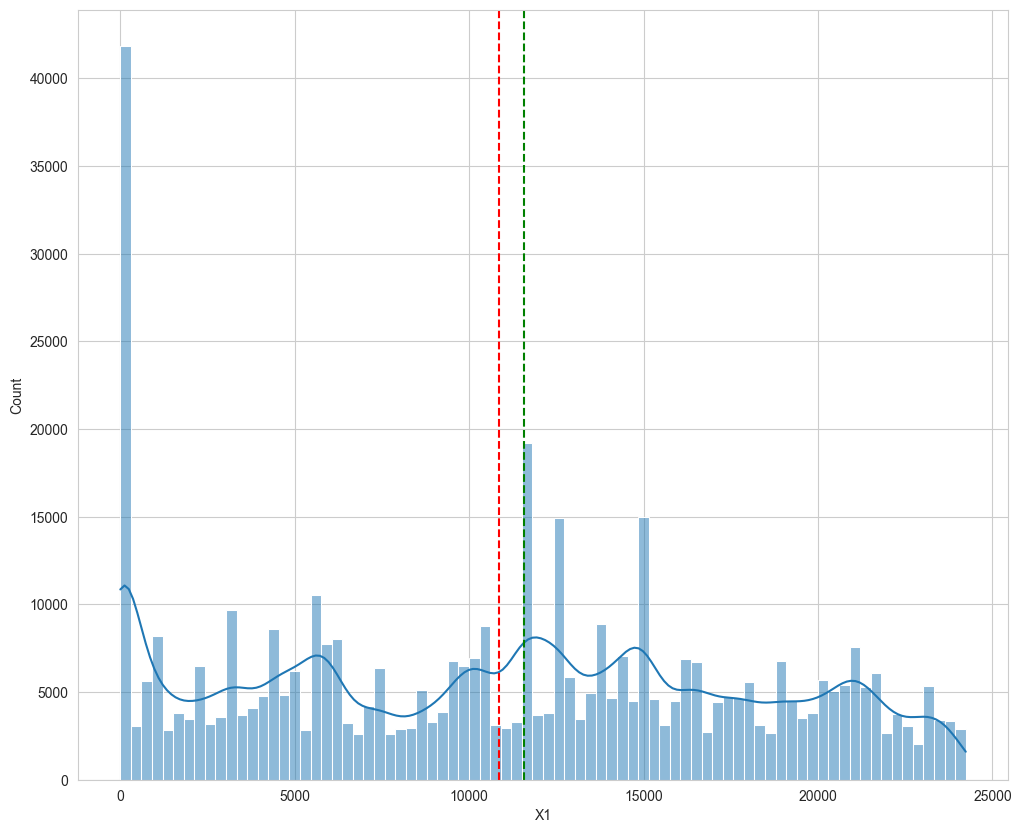

In [21]:
histo('X1')

In [22]:
df.skew().sort_values(ascending= False)

X37      118.699169
X51      117.898518
X25       91.244233
X26       49.156315
X32       42.162578
X19       30.408671
X31       29.423040
X44       24.140470
X11       23.532937
X41       20.606987
X43       15.353361
X38       13.956171
X12       11.066450
X45       10.959477
X40        9.749156
X14        8.686473
X24        8.411932
X42        7.689727
label      5.853622
X39        5.266290
X21        4.689230
X13        4.250548
X28        4.132946
X15        4.114642
X35        2.146001
X34        2.104838
X23        1.555252
X17        1.419939
X9         1.384801
X3         1.097239
X22        0.896960
X49        0.874420
X36        0.779058
X7         0.387934
X16        0.371865
X10        0.360612
X1         0.044671
X18        0.031544
X8        -0.017119
X50       -0.049178
X20       -0.049449
X5        -0.486726
X2        -0.763204
X4        -0.865404
X6        -1.048826
dtype: float64

In [23]:
# now we will the skewness in our data
skewed_cols = df.skew(numeric_only=True)[lambda x: (x>1)|(x<-1)].index
print(skewed_cols)

Index(['label', 'X3', 'X6', 'X9', 'X11', 'X12', 'X13', 'X14', 'X15', 'X17',
       'X19', 'X21', 'X23', 'X24', 'X25', 'X26', 'X28', 'X31', 'X32', 'X34',
       'X35', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45',
       'X51'],
      dtype='object')


In [24]:
len(skewed_cols)

31

here I could see that data has skewness in it so we have to check different transoformation techniques then check it's skewness in the data

In [25]:
df[skewed_cols].describe()

,label,X3,X6,X9,X11,X12,X13,X14,X15,X17,...,X37,X38,X39,X40,X41,X42,X43,X44,X45,X51
count,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,...,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000,458798.000000
mean,0.026855,28.107965,3.215446,17.663438,0.001796,0.007971,0.087452,0.019340,0.179563,1.510190,...,0.000532,0.086814,0.469900,0.019344,0.065436,0.519900,0.041033,0.074793,0.008123,0.000072
std,0.161660,19.227303,0.811902,6.338223,0.042341,0.088923,0.310596,0.149538,0.479321,1.867473,...,0.031383,0.355296,0.721578,0.152753,0.392297,1.557607,0.253398,0.432161,0.089763,0.008481
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13.000000,3.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,14.000000,3.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,37.000000,4.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,94.000000,4.000000,38.000000,1.000000,1.000000,10.000000,5.000000,14.000000,26.000000,...,10.000000,38.000000,32.000000,6.000000,56.000000,97.000000,33.000000,56.000000,1.000000,1.000000


In [26]:
X = df.drop(columns = ['label'])
y = df['label']

In [27]:
yeo_pt = PowerTransformer(method='yeo-johnson', standardize=True)

In [28]:
transformed_array = yeo_pt.fit_transform(X)

transformed_X  = pd.DataFrame(transformed_array, columns= X.columns)

In [29]:
# now we will the skewness in our data
skewed_cols = transformed_X.skew(numeric_only=True)[lambda x: (x>1)|(x<-1)].index
print(skewed_cols)

Index(['X11', 'X12', 'X13', 'X14', 'X15', 'X19', 'X24', 'X26', 'X37', 'X38',
       'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X51'],
      dtype='object')


In [30]:
len(skewed_cols)

17

In [31]:
transformed_X.skew().sort_values(ascending= False)

X51    117.898518
X37     49.239404
X11     23.532937
X26     12.234614
X12     11.066450
X45     10.959477
X40      7.333905
X14      7.302498
X43      5.117776
X41      4.308179
X44      3.994689
X19      3.573085
X38      3.209589
X13      3.079460
X24      2.557956
X15      1.935636
X42      1.301013
X25      0.894951
X49      0.874420
X32      0.784565
X35      0.759377
X28      0.711536
X34      0.694725
X31      0.690088
X39      0.437370
X36      0.198345
X17      0.192388
X23      0.116758
X3       0.112150
X22      0.071051
X16      0.021089
X18     -0.003002
X10     -0.032710
X8      -0.040954
X50     -0.049178
X20     -0.049449
X21     -0.068125
X7      -0.068645
X9      -0.145610
X6      -0.227753
X5      -0.398740
X2      -0.584630
X4      -0.591917
X1      -0.676890
dtype: float64

here in the above data even after using the powertransformer they are skewness are still not controlled yet, by this reason tree models like decision tree, XGBoost, LightGBM, and RandomForest works perfect with it.\
But even if we use these data on logistic regression, or other non-tree models there hesitate tto give perfect answer of these dataset

In [32]:
def explore_correlation(df):
  """
  Performs Exploratory Data Analysis (EDA) on a Pandas DataFrame's correlation matrix.

  Args:
    df: A Pandas DataFrame.

  Returns:
    None. Displays visualizations and prints summary information.
  """

  # 1. Calculate the Correlation Matrix
  corr_matrix = df.corr()

  # 2. Heatmap Visualization - Pearson Correlations
  plt.figure(figsize=(20, 20))  # Adjust figure size for better readability
  sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") #annot = True displays correlation values, cmap sets color scheme
  plt.title("Correlation Heatmap (Pearson)")
  plt.show()


  # 4. Correlation Matrix Summary
  print("\nCorrelation Matrix:")
  print(corr_matrix)
  return corr_matrix


def corr_matrix(mat):
    data = [(i, j) for i in range(len(mat.columns)) for j in range(i + 1, len(mat.columns))]
    print("\nStrong Positive Correlations (above 0.7):")
    for col1, col2 in data:
          if abs(mat.iloc[col1, col2]) > 0.7:
              print(f"  {mat.columns[col1]} and {mat.columns[col2]}: Correlation = {mat.iloc[col1, col2]:.2f}")

    print("\nStrong Negative Correlations (below -0.7):")
    for col1, col2 in data:
          if abs(mat.iloc[col1, col2]) > 0.7:
              print(f"  {mat.columns[col1]} and {mat.columns[col2]}: Correlation = {mat.iloc[col1, col2]:.2f}")

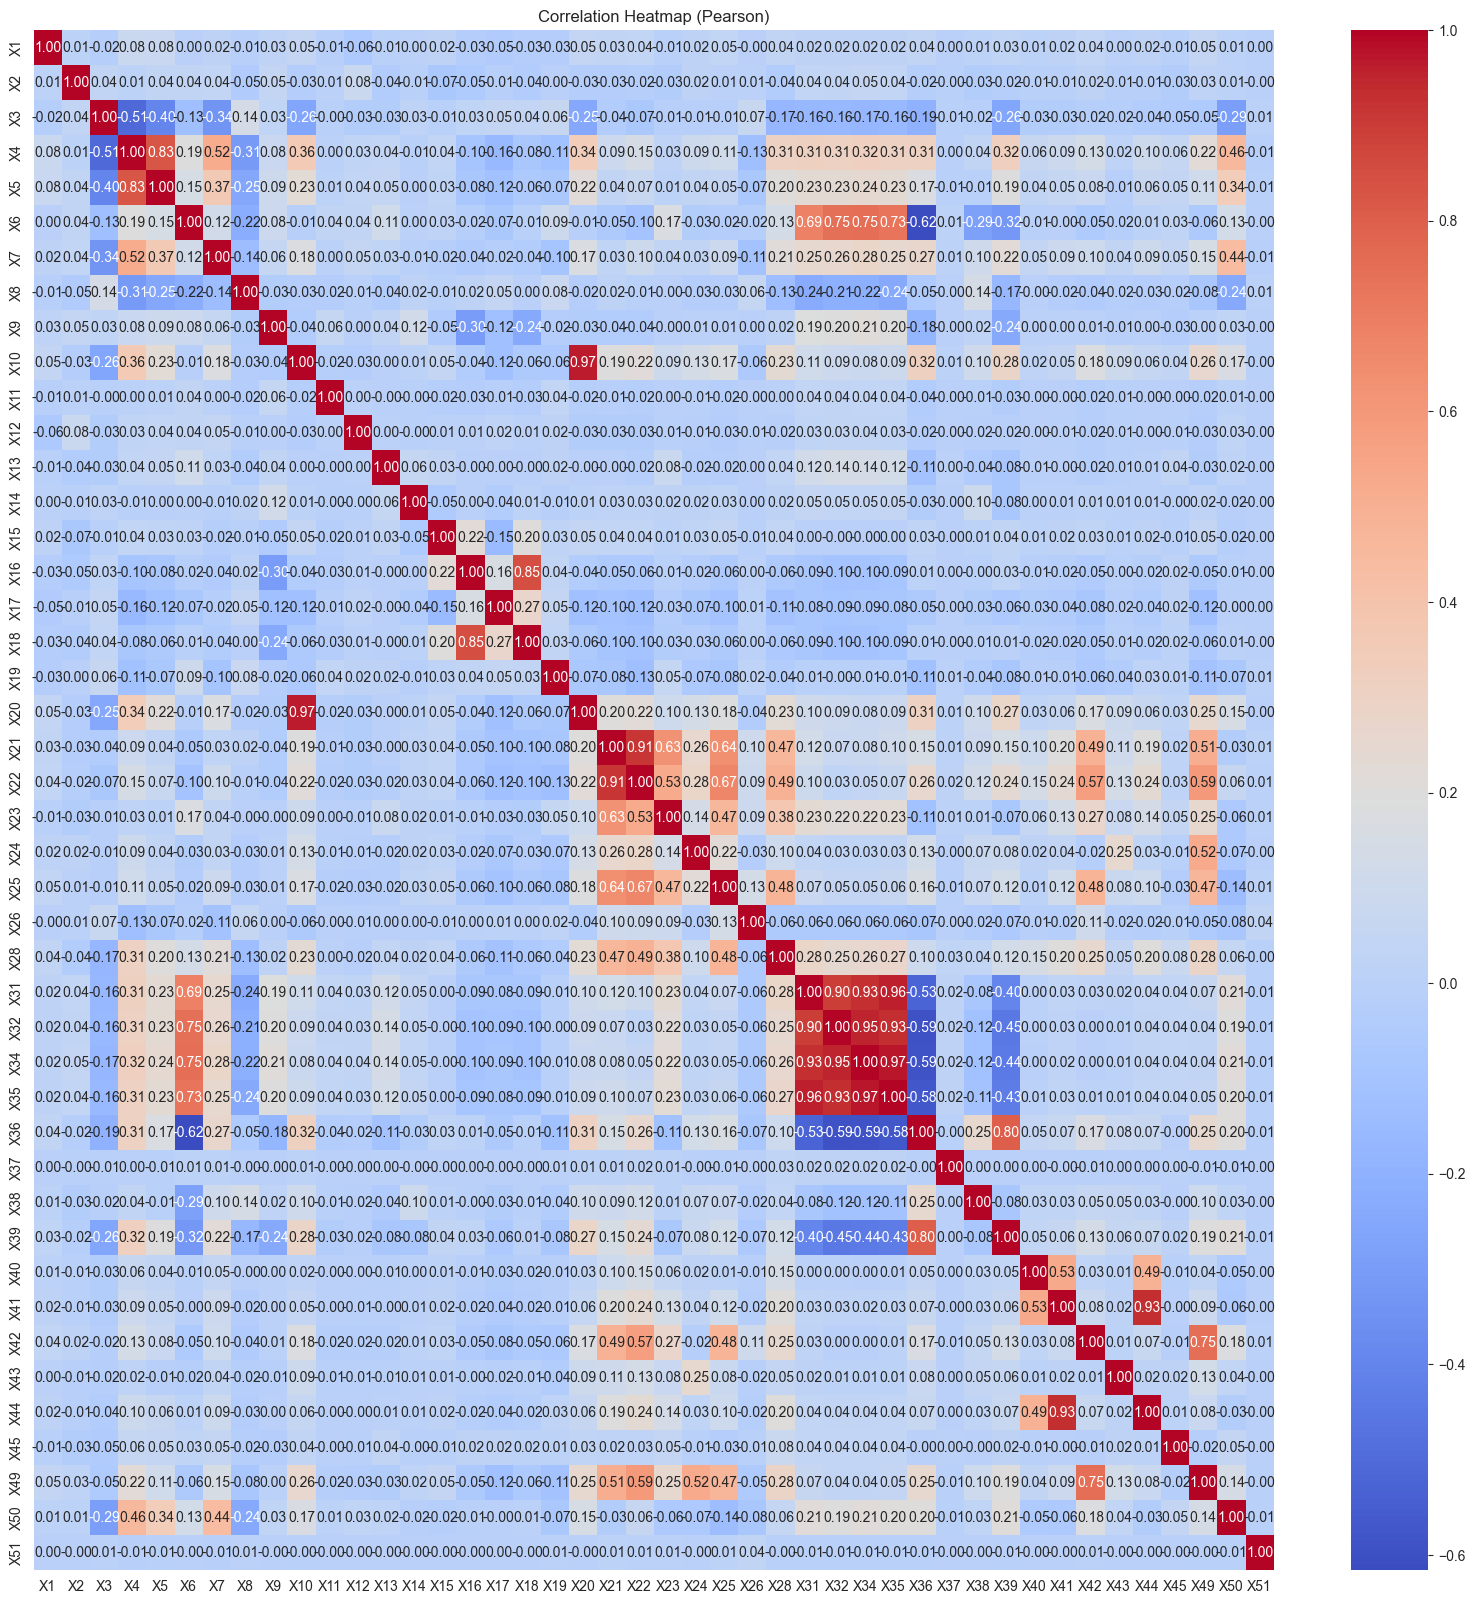


Correlation Matrix:
           X1        X2        X3        X4        X5        X6        X7  \
X1   1.000000  0.009335 -0.017373  0.080692  0.076309  0.001352  0.020211   
X2   0.009335  1.000000  0.038443  0.009636  0.040119  0.035810  0.040464   
X3  -0.017373  0.038443  1.000000 -0.508383 -0.398163 -0.127853 -0.336212   
X4   0.080692  0.009636 -0.508383  1.000000  0.825117  0.194126  0.518052   
X5   0.076309  0.040119 -0.398163  0.825117  1.000000  0.153610  0.365667   
X6   0.001352  0.035810 -0.127853  0.194126  0.153610  1.000000  0.120899   
X7   0.020211  0.040464 -0.336212  0.518052  0.365667  0.120899  1.000000   
X8  -0.010644 -0.045633  0.137602 -0.310900 -0.250067 -0.220109 -0.138379   
X9   0.026926  0.051802  0.033153  0.075690  0.094991  0.084904  0.059314   
X10  0.051387 -0.025407 -0.259409  0.356277  0.225283 -0.013376  0.177616   
X11 -0.014057  0.006500 -0.004590  0.004274  0.008956  0.039516  0.004250   
X12 -0.063427  0.079907 -0.033377  0.032059  0.041848  

In [33]:
the_matrix = explore_correlation(transformed_X)


In [ ]:
minmax_scaler = MinMaxScaler()
transformed_X = minmax_scaler.fit_transform(transformed_X)

In [ ]:
standard_scaler = StandardScaler()
transformed_X = standard_scaler.fit_transform(transformed_X)

In [ ]:
from sklearn.decomposition import PCA
pca_auto = PCA(n_components=0.95)  # keep enough components to explain 95% variance
principal_components_auto = pca_auto.fit_transform(transformed_X)

print(f"Number of components selected: {pca_auto.n_components_}")
print(f"Total variance explained: {sum(pca_auto.explained_variance_ratio_):.2f}")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [ ]:
vif_df = pd.DataFrame()
vif_df['features'] = df.columns
vif_df['VIF'] = [vif(df.values, i) for i in range(len(df.columns))]

vif_df

,features,VIF
0,label,1.202223
1,X1,3.366482
2,X2,6.118396
3,X3,3.503587
4,X4,56.557625
5,X5,14.830493
6,X6,26.231051
7,X7,5.198893
8,X8,10.978336
9,X9,9.172560


In [ ]:
df[['X4', 'X18']].head()

,X4,X18
0,3,7
1,3,9
2,3,11
3,2,7
4,2,11


In [ ]:
vif_df.sort_values(by = 'VIF', ascending=False)

,features,VIF
4,X4,56.557625
18,X18,49.741773
16,X16,38.310493
31,X35,27.850954
30,X34,27.227460
6,X6,26.231051
22,X22,20.482708
5,X5,14.830493
8,X8,10.978336
20,X20,9.182070


so we got to know that some of our data are having null values so we have to add fill null value by doing the medium vlaue of the data

### Model Building & Evaluation

In [ ]:
#let's see how model works after removing the data

def model(name: str, model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y) # as we have used the stratify value, so that we can split the data in even form
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    classification = classification_report(y_test, y_pred)
    print(f"name: {name}, Here is the Report: \n{classification}")
    


In [ ]:
model1 = LogisticRegression()
model2 = RandomForestClassifier()
model3 = DecisionTreeClassifier()
model4 = KNeighborsClassifier()
model5 = XGBClassifier()

model('RandomForestClassifier', model2,principal_components_auto, y)

name: model2, Here is the Report: 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     89296
           1       0.86      0.57      0.69      2464

    accuracy                           0.99     91760
   macro avg       0.93      0.78      0.84     91760
weighted avg       0.98      0.99      0.98     91760



In [ ]:
model('DecisionTreeClassifier', model3,principal_components_auto, y)

name: DecisionTreeClassifier, Here is the Report: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     89296
           1       0.52      0.57      0.54      2464

    accuracy                           0.97     91760
   macro avg       0.75      0.78      0.77     91760
weighted avg       0.98      0.97      0.97     91760



In [ ]:
model('XGBClassifier', model5, principal_components_auto, y)

name: XGBClassifier, Here is the Report: 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     89296
           1       0.83      0.61      0.71      2464

    accuracy                           0.99     91760
   macro avg       0.91      0.81      0.85     91760
weighted avg       0.99      0.99      0.99     91760



In [ ]:
model('Logistic Regression', model1, principal_components_auto, y)

name: Logistic Regression, Here is the Report: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     89296
           1       0.76      0.40      0.53      2464

    accuracy                           0.98     91760
   macro avg       0.87      0.70      0.76     91760
weighted avg       0.98      0.98      0.98     91760



In [ ]:
model('KNeighborsClassifier', model4, principal_components_auto, y)

name: KNeighborsClassifier, Here is the Report: 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     89296
           1       0.73      0.54      0.62      2464

    accuracy                           0.98     91760
   macro avg       0.86      0.77      0.81     91760
weighted avg       0.98      0.98      0.98     91760



In [ ]:
model6 = SVC(kernel='rbf', C=1.0, gamma = 'scale', random_state=42)
model('SVC', model6, principal_components_auto, y)

In [ ]:
model6 = lgb.LGBMClassifier()


In [ ]:
model('LightGBM', model6, principal_components_auto, y)

NameError: name 'model' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(principal_components_auto, y, test_size=0.2, random_state=42, stratify = y)

here I am going to use cross validation in my lgbm model, as it dosen't recall perfectly so to imporve it's recall we will stratifiedKflod cross validation to make more better way

In [35]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': 42,
    'verbose': -1
}

In [ ]:
models = []
oof_predictions = np.zeros(len(principal_components_auto))

In [44]:
skf = StratifiedKFold(n_splits= 5, shuffle = True, random_state = 42)

# cross validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    train_X, train_y = transformed_X.iloc[train_idx], y.iloc[train_idx]
    val_X, val_y = transformed_X.iloc[val_idx], y.iloc[val_idx]

    trn_data = lgb.Dataset(train_X, label=train_y)
    val_data = lgb.Dataset(val_X, label = val_y)

    model  = lgb.train(
        params,
        trn_data,
        num_boost_round = 1000,
        valid_sets = [trn_data, val_data],
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose = False),
            lgb.log_evaluation(period = 100)   
        ]
    )

    models.append(model)
    oof_predictions[val_idx] = model.predict(data = val_X, num_iteration= model.best_iteration)


[100]	training's binary_logloss: 0.0480299	valid_1's binary_logloss: 0.0522293
[200]	training's binary_logloss: 0.0423351	valid_1's binary_logloss: 0.0497483
[300]	training's binary_logloss: 0.0391437	valid_1's binary_logloss: 0.049
[400]	training's binary_logloss: 0.0364425	valid_1's binary_logloss: 0.0483488
[500]	training's binary_logloss: 0.0343494	valid_1's binary_logloss: 0.0480543
[600]	training's binary_logloss: 0.0324381	valid_1's binary_logloss: 0.0478741
[700]	training's binary_logloss: 0.0307472	valid_1's binary_logloss: 0.0476692
[800]	training's binary_logloss: 0.0293563	valid_1's binary_logloss: 0.0475902
[100]	training's binary_logloss: 0.0483471	valid_1's binary_logloss: 0.0516688
[200]	training's binary_logloss: 0.0427865	valid_1's binary_logloss: 0.0495296
[300]	training's binary_logloss: 0.0397946	valid_1's binary_logloss: 0.0488704
[400]	training's binary_logloss: 0.0372338	valid_1's binary_logloss: 0.0485845
[500]	training's binary_logloss: 0.0349902	valid_1's bin

In [47]:
combined_test_probs = np.zeros(len(y_test))

threshold = 0.5

for model in models:
    combined_test_probs += model.predict(X_test, num_interation =model.best_iteration)


final_avg_probs = combined_test_probs/len(models)

final_pred_class = (final_avg_probs > threshold).astype(int)

final_recall = recall_score(y_test, final_pred_class)

print(f'ensembled final test recall: {final_recall: .4f}')

ensembled final test recall:  0.6782


so here we see that we secured around of 67% recall from 61% of recall which is good jump, and now we will be delpoying the model in pickle file.

In [ ]:
import pickle

model_pickel_path = 'lgbm_ensemble method.pkl'

with open(model_pickel_path, 'wb') as f :
    pickle.dump(models, f)



NameError: name 'model_pkl_path' is not defined

In [49]:
print(f"Successfully saved all {len(models)} fold models to {model_pickel_path}")

Successfully saved all 5 fold models to lgbm_ensemble method.pkl
